# Figure 3C (UHVDB r6). Functional annotation

Revision of `figure_3c.ipynb` using UHVDB r6 protein annotations and metadata
(`toolkit2/databases/uhvdb/v6/analyze/`).

UniRef hit levels still use Bakta Accession + percent identity (Id):
UniRef50 = UniRef90 accessions with `0.5 <= Id < 0.9`. Because the r6
consolidated parquet omits Id, Bakta/Pharokka/Phold tables are taken from
the r4 release plus the r6 `new_proteins_*` catheader outputs.


In [1]:
### Load packages
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

REPO = Path('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB')
ANN = REPO / 'toolkit2/databases/uhvdb/v6/analyze/uhvdb_protein_annotations.parquet'
META = REPO / 'toolkit2/databases/uhvdb/v6/analyze/uhvdb_metadata.tsv.gz'
RELEASE_R4 = (
    REPO / 'uhvdb-manuscript/figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2'
)
NEW_FUNC = (
    REPO
    / 'uhvdb-manuscript-update/figure_1/results_function/function/uhvdb_catheader'
)
OUTDIR = Path('plots')
OUTDIR.mkdir(exist_ok=True)


In [2]:
## load consolidated protein annotations (r6)
# Unique hashes among genomovar-representative proteins define the analysis universe.
# Lazy scan + column pruning + streaming collect to limit peak memory.
# UniRef hit levels are assigned later from Bakta Accession + percent identity (Id).
ann_lf = (
    pl.scan_parquet(ANN)
    .select([
        'hash',
        'foldseek_acc',
        'ips_id',
        'card_acc',
        'vfdb_acc',
        'pharokka_annot',
        'phold_category',
        'empathi_annot',
    ])
    .unique(subset=['hash'])
    .with_columns([
        pl.col('foldseek_acc').fill_null(''),
        pl.col('ips_id').fill_null(''),
        pl.col('card_acc').fill_null(''),
        pl.col('vfdb_acc').fill_null(''),
        pl.col('pharokka_annot').fill_null(''),
        pl.col('phold_category').fill_null(''),
        pl.col('empathi_annot').fill_null(''),
    ])
    .with_columns([
        (pl.col('foldseek_acc').str.strip_chars() != '').alias('has_foldseek'),
        (pl.col('ips_id').str.strip_chars() != '').alias('has_ips'),
        (pl.col('card_acc').str.strip_chars() != '').alias('has_card'),
        (pl.col('vfdb_acc').str.strip_chars() != '').alias('has_vfdb'),
        pl.when(pl.col('pharokka_annot').str.strip_chars() == '')
            .then(pl.lit(None, dtype=pl.Utf8))
            .when(pl.col('pharokka_annot') == 'hypothetical protein')
            .then(pl.lit('hypothetical'))
            .otherwise(pl.lit('function'))
            .alias('pharokka_hit_type'),
        pl.when(pl.col('phold_category').str.strip_chars() == '')
            .then(pl.lit(None, dtype=pl.Utf8))
            .when(pl.col('phold_category') == 'unknown function')
            .then(pl.lit('hypothetical'))
            .otherwise(pl.lit('function'))
            .alias('phold_hit_type'),
        (
            (pl.col('empathi_annot').str.strip_chars() != '')
            & (pl.col('empathi_annot') != 'unknown')
        ).alias('has_empathi'),
    ])
    .select([
        'hash',
        'has_foldseek',
        'has_ips',
        'has_card',
        'has_vfdb',
        'pharokka_hit_type',
        'phold_hit_type',
        'has_empathi',
    ])
)

try:
    ann = ann_lf.collect(engine='streaming')
except TypeError:
    ann = ann_lf.collect(streaming=True)

total_proteins = ann.height
print(f'Total unique proteins in genomovars: {total_proteins:,}')


Total unique proteins in genomovars: 22,619,873


In [3]:
## enrich annotations from r4 release + r6 new-protein tables
# 1) UniRef levels from Bakta Accession + percent identity (Id)
#    UniRef50 = UniRef90 accessions with 0.5 <= Id < 0.9
# 2) Pharokka / Phold hypotheticals (omitted from consolidated annotations)
# Prefer new-protein rows when a hash appears in both sources.
hash_lf = ann.select('hash').lazy()


def _bakta_levels_lf(path: Path) -> pl.LazyFrame:
    return (
        pl.scan_csv(
            path,
            separator='\t',
            skip_rows=5,
            null_values=['-', ''],
        )
        .select([
            pl.col('Locus Tag').alias('hash'),
            pl.col('Accession').alias('bakta_acc'),
            pl.col('Id').cast(pl.Float64, strict=False).alias('bakta_id'),
        ])
        .filter(pl.col('bakta_acc').is_not_null())
        .unique('hash')
        .join(hash_lf, on='hash', how='semi')
        .with_columns(
            pl.when(pl.col('bakta_acc').str.contains('UniRef100'))
                .then(pl.lit('UniRef100'))
                .when(pl.col('bakta_acc').str.contains('UniRef90') & (pl.col('bakta_id') >= 0.9))
                .then(pl.lit('UniRef90'))
                .when(pl.col('bakta_acc').str.contains('UniRef90') & (pl.col('bakta_id') >= 0.5))
                .then(pl.lit('UniRef50'))
                .when(pl.col('bakta_acc').str.contains('UniRef90') & (pl.col('bakta_id') >= 0.3))
                .then(pl.lit('UniRef30'))
                .when(pl.col('bakta_acc').str.contains('UniRef50') & (pl.col('bakta_id') >= 0.5))
                .then(pl.lit('UniRef50'))
                .when(pl.col('bakta_acc').str.contains('UniRef30'))
                .then(pl.lit('UniRef30'))
                .otherwise(pl.lit('No match'))
                .alias('uniprot_hit_level')
        )
        .select(['hash', 'uniprot_hit_level'])
    )


def _pharokka_types_lf(path: Path) -> pl.LazyFrame:
    return (
        pl.scan_csv(path, separator='\t')
            .filter(pl.col('phrog') != 'No_PHROGs_HMM')
            .select(pl.col('ID').alias('hash'), 'annot')
            .unique('hash')
            .join(hash_lf, on='hash', how='semi')
            .with_columns(
                pl.when(pl.col('annot') == 'hypothetical protein')
                    .then(pl.lit('hypothetical'))
                    .otherwise(pl.lit('function'))
                    .alias('pharokka_hit_type')
            )
            .select(['hash', 'pharokka_hit_type'])
    )


def _phold_types_lf(path: Path) -> pl.LazyFrame:
    return (
        pl.scan_csv(path, separator='\t')
            .filter(pl.col('phrog') != 'No_PHROG')
            .select(pl.col('cds_id').alias('hash'), 'function')
            .unique('hash')
            .join(hash_lf, on='hash', how='semi')
            .with_columns(
                pl.when(pl.col('function') == 'unknown function')
                    .then(pl.lit('hypothetical'))
                    .otherwise(pl.lit('function'))
                    .alias('phold_hit_type')
            )
            .select(['hash', 'phold_hit_type'])
    )


def _prefer_new(old_lf: pl.LazyFrame, new_lf: pl.LazyFrame, cols: list[str]) -> pl.LazyFrame:
    # Keep new rows first so unique('hash') retains the r6 annotation.
    return pl.concat([new_lf, old_lf], how='vertical_relaxed').unique('hash', keep='first').select(cols)


bakta_levels_lf = _prefer_new(
    _bakta_levels_lf(RELEASE_R4 / 'uhvdb_bakta.tsv.gz'),
    _bakta_levels_lf(NEW_FUNC / 'new_proteins_bakta.tsv.gz'),
    ['hash', 'uniprot_hit_level'],
)
pharokka_types_lf = _prefer_new(
    _pharokka_types_lf(RELEASE_R4 / 'uhvdb_pharokka.tsv.gz'),
    _pharokka_types_lf(NEW_FUNC / 'new_proteins_pharokka.tsv.gz'),
    ['hash', 'pharokka_hit_type'],
)
phold_types_lf = _prefer_new(
    _phold_types_lf(RELEASE_R4 / 'uhvdb_phold.tsv.gz'),
    _phold_types_lf(NEW_FUNC / 'new_proteins_phold.tsv.gz'),
    ['hash', 'phold_hit_type'],
)

try:
    bakta_levels = bakta_levels_lf.collect(engine='streaming')
    pharokka_types = pharokka_types_lf.collect(engine='streaming')
    phold_types = phold_types_lf.collect(engine='streaming')
except TypeError:
    bakta_levels = bakta_levels_lf.collect(streaming=True)
    pharokka_types = pharokka_types_lf.collect(streaming=True)
    phold_types = phold_types_lf.collect(streaming=True)

# Accession-only fallback for r6 hashes absent from Bakta Id tables
bakta_acc_fallback_lf = (
    pl.scan_parquet(ANN)
        .select(['hash', 'bakta_acc'])
        .unique('hash')
        .join(hash_lf, on='hash', how='semi')
        .join(bakta_levels_lf.select('hash'), on='hash', how='anti')
        .filter(pl.col('bakta_acc').is_not_null() & (pl.col('bakta_acc').str.strip_chars() != ''))
        .with_columns(
            pl.when(pl.col('bakta_acc').str.contains('UniRef100'))
                .then(pl.lit('UniRef100'))
                .when(pl.col('bakta_acc').str.contains('UniRef90'))
                .then(pl.lit('UniRef90'))  # Id unavailable; cannot split UniRef50
                .when(pl.col('bakta_acc').str.contains('UniRef50'))
                .then(pl.lit('UniRef50'))
                .when(pl.col('bakta_acc').str.contains('UniRef30'))
                .then(pl.lit('UniRef30'))
                .otherwise(pl.lit('No match'))
                .alias('uniprot_hit_level')
        )
        .select(['hash', 'uniprot_hit_level'])
)

try:
    bakta_acc_fallback = bakta_acc_fallback_lf.collect(engine='streaming')
except TypeError:
    bakta_acc_fallback = bakta_acc_fallback_lf.collect(streaming=True)

bakta_levels = pl.concat([bakta_levels, bakta_acc_fallback]).unique('hash', keep='first')
print(f'Bakta Id-table levels: {bakta_levels.height - bakta_acc_fallback.height:,}')
print(f'Bakta accession-only fallback: {bakta_acc_fallback.height:,}')

ann = (
    ann.drop(['pharokka_hit_type', 'phold_hit_type'])
        .join(bakta_levels, on='hash', how='left')
        .with_columns(pl.col('uniprot_hit_level').fill_null('No match'))
        .join(pharokka_types, on='hash', how='left')
        .join(phold_types, on='hash', how='left')
)

print(ann.group_by('uniprot_hit_level').len().sort('uniprot_hit_level'))
print(
    'Pharokka:',
    ann.filter(pl.col('pharokka_hit_type') == 'function').height,
    'function /',
    ann.filter(pl.col('pharokka_hit_type') == 'hypothetical').height,
    'hypothetical',
)
print(
    'Phold:',
    ann.filter(pl.col('phold_hit_type') == 'function').height,
    'function /',
    ann.filter(pl.col('phold_hit_type') == 'hypothetical').height,
    'hypothetical',
)


Bakta Id-table levels: 14,981,151
Bakta accession-only fallback: 360,202
shape: (5, 2)
┌───────────────────┬─────────┐
│ uniprot_hit_level ┆ len     │
│ ---               ┆ ---     │
│ str               ┆ u32     │
╞═══════════════════╪═════════╡
│ No match          ┆ 7282745 │
│ UniRef100         ┆ 814613  │
│ UniRef30          ┆ 8281085 │
│ UniRef50          ┆ 2756904 │
│ UniRef90          ┆ 3484526 │
└───────────────────┴─────────┘
Pharokka: 8477050 function / 4090103 hypothetical
Phold: 1728259 function / 1010648 hypothetical


In [4]:
bakta_stats = (
    ann
        .group_by('uniprot_hit_level').len()
        .sort('uniprot_hit_level')
)
bakta_stats


uniprot_hit_level,len
str,u32
"""No match""",7282745
"""UniRef100""",814613
"""UniRef30""",8281085
"""UniRef50""",2756904
"""UniRef90""",3484526


In [5]:
n_foldseek = ann.filter(pl.col('has_foldseek')).height
n_interproscan = ann.filter(pl.col('has_ips')).height
n_foldseek, n_interproscan


(419434, 2632346)

In [6]:
pharokka_stats = (
    ann
        .filter(pl.col('pharokka_hit_type').is_not_null())
        .group_by(pl.col('pharokka_hit_type').alias('phrog_hit_type')).len()
        .sort('phrog_hit_type')
)
pharokka_stats


phrog_hit_type,len
str,u32
"""function""",8477050
"""hypothetical""",4090103


In [7]:
phold_stats = (
    ann
        .filter(pl.col('phold_hit_type').is_not_null())
        .group_by(pl.col('phold_hit_type').alias('phrog_hit_type')).len()
        .sort('phrog_hit_type')
)
phold_stats


phrog_hit_type,len
str,u32
"""function""",1728259
"""hypothetical""",1010648


In [8]:
def _stat_count(stats_df, level):
    hit = stats_df.filter(pl.col('uniprot_hit_level') == level)
    return int(hit['len'][0]) if hit.height else 0

# Cumulative order: UniRef100 -> UniRef90 -> UniRef50 -> UniRef30 -> Foldseek -> InterProScan
uniprot_stats = (
    pl.DataFrame({
        'method': ['UniRef100', 'UniRef90', 'UniRef50', 'UniRef30', 'Foldseek', 'InterProScan'],
        'count': [
            _stat_count(bakta_stats, 'UniRef100'),
            _stat_count(bakta_stats, 'UniRef90'),
            _stat_count(bakta_stats, 'UniRef50'),
            _stat_count(bakta_stats, 'UniRef30'),
            n_foldseek,
            n_interproscan,
        ]
    })
    .with_columns([
        pl.col('count').cum_sum().alias('cumulative_count')
    ])
)
uniprot_stats


method,count,cumulative_count
str,i64,i64
"""UniRef100""",814613,814613
"""UniRef90""",3484526,4299139
"""UniRef50""",2756904,7056043
"""UniRef30""",8281085,15337128
"""Foldseek""",419434,15756562
"""InterProScan""",2632346,18388908


In [9]:
# Fraction of proteins with UniRef or Foldseek hits
uniprot_foldseek_count = (
    uniprot_stats.filter(
        pl.col('method').is_in(['UniRef100', 'UniRef90', 'UniRef50', 'UniRef30', 'Foldseek'])
    )['count'].sum()
)
uniprot_foldseek_count / total_proteins


0.6965804803590188

In [10]:
# Fraction of proteins with InterProScan hits
n_interproscan / total_proteins


0.11637315558756674

In [ ]:
# Fraction of unique proteins / genomovars with UniRef OR Foldseek OR InterProScan
has_uniref = pl.col('uniprot_hit_level') != 'No match'
has_uniref_foldseek_ips = has_uniref | pl.col('has_foldseek') | pl.col('has_ips')

n_proteins_annotated = ann.filter(has_uniref_foldseek_ips).height
prop_proteins_annotated = n_proteins_annotated / total_proteins
print(
    f'Unique proteins with UniRef / Foldseek / InterProScan: '
    f'{n_proteins_annotated:,} / {total_proteins:,} ({prop_proteins_annotated:.2%})'
)

# Genomovar-level: any protein on the genomovar representative has a hit
genomovar_ann = (
    pl.scan_parquet(ANN)
    .select(['genomovar_rep', 'hash', 'foldseek_acc', 'ips_id'])
    .unique(subset=['genomovar_rep', 'hash'])
    .join(
        ann.select(['hash', 'uniprot_hit_level', 'has_foldseek', 'has_ips']).lazy(),
        on='hash',
        how='left',
    )
    .with_columns([
        pl.col('uniprot_hit_level').fill_null('No match'),
        pl.col('has_foldseek').fill_null(False),
        pl.col('has_ips').fill_null(False),
    ])
    .group_by('genomovar_rep')
    .agg(
        (
            (pl.col('uniprot_hit_level') != 'No match').any()
            | pl.col('has_foldseek').any()
            | pl.col('has_ips').any()
        ).alias('has_uniref_foldseek_ips')
    )
)

try:
    genomovar_ann = genomovar_ann.collect(engine='streaming')
except TypeError:
    genomovar_ann = genomovar_ann.collect(streaming=True)

n_genomovars = genomovar_ann.height
n_genomovars_annotated = genomovar_ann.filter(pl.col('has_uniref_foldseek_ips')).height
prop_genomovars_annotated = n_genomovars_annotated / n_genomovars
print(
    f'Genomovars with >=1 UniRef / Foldseek / InterProScan protein: '
    f'{n_genomovars_annotated:,} / {n_genomovars:,} ({prop_genomovars_annotated:.2%})'
)
prop_genomovars_annotated

In [11]:
def _phrog_count(stats_df, hit_type):
    hit = stats_df.filter(pl.col('phrog_hit_type') == hit_type)
    return int(hit['len'][0]) if hit.height else 0

n_pharokka_function = _phrog_count(pharokka_stats, 'function')
n_phold_function = _phrog_count(phold_stats, 'function')
n_pharokka_hypothetical = _phrog_count(pharokka_stats, 'hypothetical')
n_phold_hypothetical = _phrog_count(phold_stats, 'hypothetical')

# Exclude any Pharokka/Phold hit (function or hypothetical) to avoid Empathi double-counting
phrog_hits = set(
    ann.filter(
        pl.col('pharokka_hit_type').is_not_null()
        | pl.col('phold_hit_type').is_not_null()
    )['hash']
)
n_empathi_exclusive = ann.filter(pl.col('has_empathi') & ~pl.col('hash').is_in(phrog_hits)).height

phage_stats = (
    pl.DataFrame({
        'method': ['Pharokka', 'Phold', 'Empathi'],
        'count': [
            n_pharokka_function,
            n_phold_function,
            n_empathi_exclusive,
        ]
    })
    .with_columns([
        pl.col('count').cum_sum().alias('cumulative_count')
    ])
)
phage_stats


method,count,cumulative_count
str,i64,i64
"""Pharokka""",8477050,8477050
"""Phold""",1728259,10205309
"""Empathi""",3696523,13901832


In [12]:
n_pharokka_hypothetical, n_phold_hypothetical


(4090103, 1010648)

In [13]:
# Fraction with Pharokka or Phold functional annotations
(n_pharokka_function + n_phold_function) / total_proteins


0.4511656188343763

In [14]:
# Fraction with Pharokka or Phold annotations (function + hypothetical)
(n_pharokka_function + n_phold_function + n_pharokka_hypothetical + n_phold_hypothetical) / total_proteins


0.6766642765854609

In [15]:
# Fraction with Empathi annotations exclusive of Pharokka/Phold function
n_empathi_exclusive / total_proteins


0.1634192641134634

In [16]:
# Fraction with Pharokka function, Phold function, or exclusive Empathi
(n_pharokka_function + n_phold_function + n_empathi_exclusive) / total_proteins


0.6145848829478398

In [ ]:
# Fraction of unique proteins with Pharokka, Phold, and/or Empathi hits
# (Pharokka/Phold: function or hypothetical; Empathi: any non-unknown annotation)
n_pharokka_hit = ann.filter(pl.col('pharokka_hit_type').is_not_null()).height
n_phold_hit = ann.filter(pl.col('phold_hit_type').is_not_null()).height
n_empathi_hit = ann.filter(pl.col('has_empathi')).height
n_phage_any = ann.filter(
    pl.col('pharokka_hit_type').is_not_null()
    | pl.col('phold_hit_type').is_not_null()
    | pl.col('has_empathi')
).height

print(f'Pharokka: {n_pharokka_hit:,} / {total_proteins:,} ({n_pharokka_hit / total_proteins:.2%})')
print(f'Phold:    {n_phold_hit:,} / {total_proteins:,} ({n_phold_hit / total_proteins:.2%})')
print(f'Empathi:  {n_empathi_hit:,} / {total_proteins:,} ({n_empathi_hit / total_proteins:.2%})')
print(
    f'Any of Pharokka / Phold / Empathi: '
    f'{n_phage_any:,} / {total_proteins:,} ({n_phage_any / total_proteins:.2%})'
)
n_phage_any / total_proteins

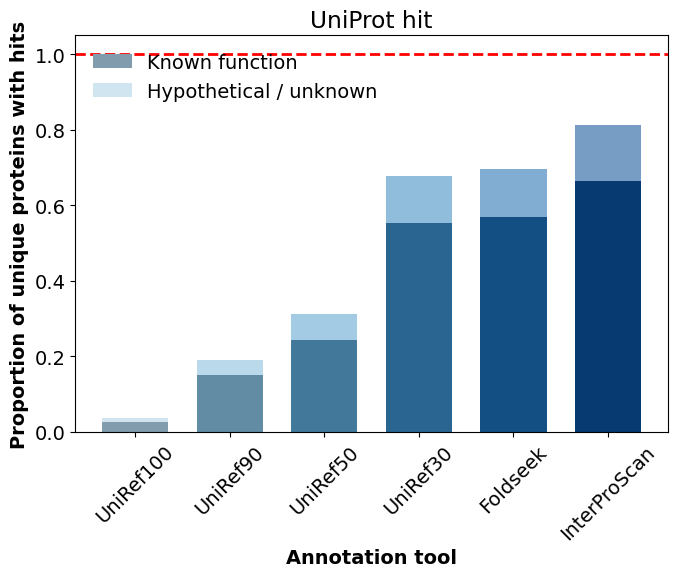

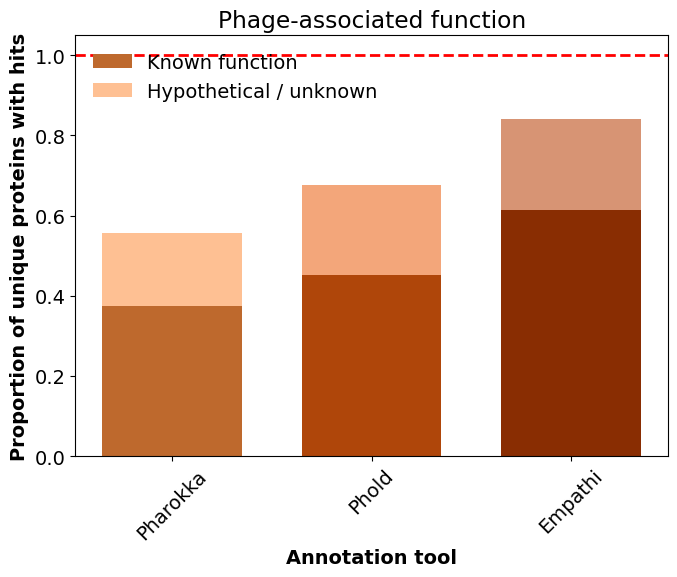

In [17]:
plt.rcParams.update({'font.size': 14})

# Known function for UniProt panel = also has phage/Empathi functional annotation
ann_plot = ann.with_columns(
    (
        (pl.col('pharokka_hit_type') == 'function')
        | (pl.col('phold_hit_type') == 'function')
        | pl.col('has_empathi')
    ).alias('has_known_function')
)

def method_known_hypo(mask: pl.Expr):
    sub = ann_plot.filter(mask)
    known = sub.filter(pl.col('has_known_function')).height
    hypo = sub.height - known
    return known, hypo

def stacked_cumulative_figure(methods, known_counts, hypo_counts, title, cmap_name, outfile=None):
    known_cum = np.cumsum(np.asarray(known_counts, dtype=float)) / total_proteins
    hypo_cum = np.cumsum(np.asarray(hypo_counts, dtype=float)) / total_proteins

    base = sns.color_palette(cmap_name, n_colors=len(methods) + 2)[2:]
    dark_colors = [tuple(np.clip(np.asarray(c, dtype=float) * 0.75, 0, 1)) for c in base]
    light_colors = [
        tuple(np.clip(np.asarray(c, dtype=float) + (1 - np.asarray(c, dtype=float)) * 0.45, 0, 1))
        for c in base
    ]

    x = np.arange(len(methods))
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.bar(x, known_cum, color=dark_colors, label='Known function', width=0.7)
    ax.bar(x, hypo_cum, bottom=known_cum, color=light_colors, label='Hypothetical / unknown', width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=45)
    ax.set_title(title)
    ax.set_xlabel('Annotation tool', fontweight='bold')
    ax.set_ylabel('Proportion of unique proteins with hits', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    if outfile is not None:
        fig.savefig(outfile, dpi=300, bbox_inches='tight')
    plt.show()

# UniProt / InterProScan cumulative order
uniprot_methods = ['UniRef100', 'UniRef90', 'UniRef50', 'UniRef30', 'Foldseek', 'InterProScan']
uniprot_known = []
uniprot_hypo = []
for method in uniprot_methods:
    if method.startswith('UniRef'):
        known, hypo = method_known_hypo(pl.col('uniprot_hit_level') == method)
    elif method == 'Foldseek':
        known, hypo = method_known_hypo(pl.col('has_foldseek'))
    else:
        known, hypo = method_known_hypo(pl.col('has_ips'))
    uniprot_known.append(known)
    uniprot_hypo.append(hypo)

stacked_cumulative_figure(
    uniprot_methods,
    uniprot_known,
    uniprot_hypo,
    'UniProt hit',
    'Blues',
    outfile=OUTDIR / 'figure_3c_uniprot_r6.png',
)

# Phage-associated function: cumulative Pharokka -> Phold -> Empathi
# Empathi excludes all prior Pharokka/Phold hits (function + hypothetical)
phage_methods = ['Pharokka', 'Phold', 'Empathi']
phage_known = [n_pharokka_function, n_phold_function, n_empathi_exclusive]
phage_hypo = [n_pharokka_hypothetical, n_phold_hypothetical, 0]

stacked_cumulative_figure(
    phage_methods,
    phage_known,
    phage_hypo,
    'Phage-associated function',
    'Oranges',
    outfile=OUTDIR / 'figure_3c_phage_r6.png',
)


In [18]:
## CARD hits from consolidated annotations
combined_card = ann.filter(pl.col('has_card')).select('hash').unique()
combined_card


hash
str
"""428bb9dc0cc8f5d28719d662604112…"
"""8afd377723517c71418d10c1cb50b9…"
"""b55b0ee5fd46371c4f8b9e577c4e94…"
"""84849d9cc0934ffe41a019a0119d6a…"
"""e2fca03030dd27a680871ecf3a2608…"
…
"""3b25b5310b0055a90cf69ae11d3cdd…"
"""cbfdb68ea5ef4810f7b53bdaefe12a…"
"""53ba5be47baf7e624900c649c0c959…"


In [ ]:
## VFDB hits from consolidated annotations
combined_vfdb = ann.filter(pl.col('has_vfdb')).select('hash').unique()
combined_vfdb

hash
str
"""92c3a7ac69bc504e68223d052fcad9…"
"""20a8ce89d219d23425829e2bd91f5d…"
"""a45dd1682181faa287b2b2adac9a02…"
"""b81f3a1542979e10a58e2b8e322df3…"
"""9e6e2df94d8d6a4d3698317d4e4aab…"
…
"""b11bc9b2ec4fedcc646b00797bda03…"
"""e086b37a61e86df6e8b5e42a4951cf…"
"""c54b74d564052691538797f870b9b3…"


Total genomovar genomes: 925,595
shape: (3, 3)
┌─────────────────────────┬────────────┬───────┐
│ category                ┆ proportion ┆ count │
│ ---                     ┆ ---        ┆ ---   │
│ str                     ┆ f64        ┆ i64   │
╞═════════════════════════╪════════════╪═══════╡
│ ARG (CARD)              ┆ 0.000831   ┆ 769   │
│ Virulence factor (VFDB) ┆ 0.012039   ┆ 11143 │
│ ARG or VF               ┆ 0.01274    ┆ 11792 │
└─────────────────────────┴────────────┴───────┘


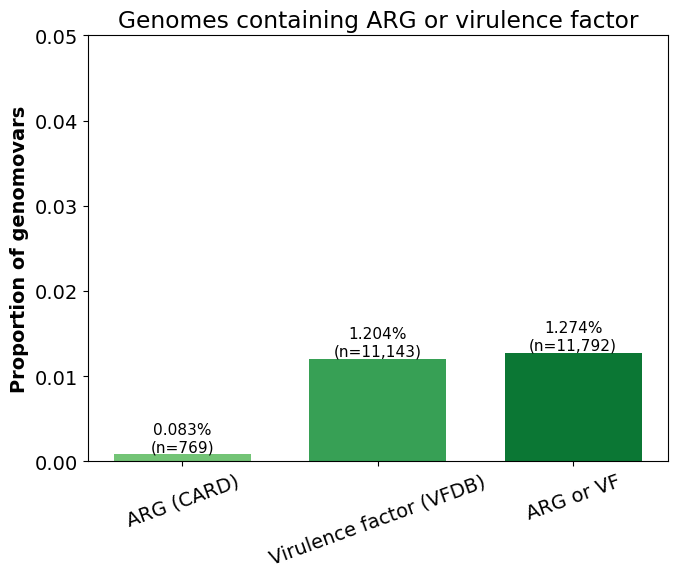

In [20]:
## Proportion of genomes with ARG (CARD) or virulence factor (VFDB)
genome_amr_vf = (
    pl.scan_parquet(ANN)
    .select(['genomovar_rep', 'card_acc', 'vfdb_acc'])
    .with_columns([
        (pl.col('card_acc').fill_null('').str.strip_chars() != '').alias('has_card'),
        (pl.col('vfdb_acc').fill_null('').str.strip_chars() != '').alias('has_vfdb'),
    ])
    .group_by('genomovar_rep')
    .agg([
        pl.col('has_card').any().alias('has_arg'),
        pl.col('has_vfdb').any().alias('has_vf'),
    ])
)

try:
    genome_amr_vf = genome_amr_vf.collect(engine='streaming')
except TypeError:
    genome_amr_vf = genome_amr_vf.collect(streaming=True)

genome_amr_vf = genome_amr_vf.with_columns(
    (pl.col('has_arg') | pl.col('has_vf')).alias('has_arg_or_vf')
)

n_genomes = genome_amr_vf.height
genome_props = pl.DataFrame({
    'category': ['ARG (CARD)', 'Virulence factor (VFDB)', 'ARG or VF'],
    'proportion': [
        genome_amr_vf['has_arg'].mean(),
        genome_amr_vf['has_vf'].mean(),
        genome_amr_vf['has_arg_or_vf'].mean(),
    ],
    'count': [
        int(genome_amr_vf['has_arg'].sum()),
        int(genome_amr_vf['has_vf'].sum()),
        int(genome_amr_vf['has_arg_or_vf'].sum()),
    ],
})
print(f'Total genomovar genomes: {n_genomes:,}')
print(genome_props)

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(7, 6))
colors = sns.color_palette('Greens', n_colors=5)[2:]
ax.bar(
    genome_props['category'].to_list(),
    genome_props['proportion'].to_list(),
    color=colors,
    width=0.7,
)
ax.set_ylabel('Proportion of genomovars', fontweight='bold')
ax.set_xlabel('')
ax.set_title('Genomes containing ARG or virulence factor')
ax.set_ylim(0, max(0.05, float(genome_props['proportion'].max()) * 1.25))
ax.tick_params(axis='x', rotation=20)
for i, (prop, count) in enumerate(zip(genome_props['proportion'].to_list(), genome_props['count'].to_list())):
    ax.text(i, prop, f'{prop:.3%}\n(n={count:,})', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
fig.savefig(OUTDIR / 'figure_3c_arg_vf_r6.png', dpi=300, bbox_inches='tight')
plt.show()


Caudoviricetes genomovar representatives: 809,328
Caudoviricetes protein annotation rows: 55,677,396
shape: (9, 6)
┌────────────────────┬──────┬──────────────┬──────────────┬────────────────────┬───────────────────┐
│ Hallmark           ┆ step ┆ method_added ┆ method_label ┆ n_genomovars_singl ┆ prop_genomovars_s │
│ ---                ┆ ---  ┆ ---          ┆ ---          ┆ e_copy_cumul…      ┆ ingle_copy_cu…    │
│ str                ┆ i64  ┆ str          ┆ str          ┆ ---                ┆ ---               │
│                    ┆      ┆              ┆              ┆ i64                ┆ f64               │
╞════════════════════╪══════╪══════════════╪══════════════╪════════════════════╪═══════════════════╡
│ Major head protein ┆ 1    ┆ annot        ┆ Pharokka     ┆ 604618             ┆ 0.747062          │
│ Major head protein ┆ 2    ┆ product      ┆ Phold        ┆ 622223             ┆ 0.768814          │
│ Major head protein ┆ 3    ┆ Annotation   ┆ Empathi      ┆ 714466           

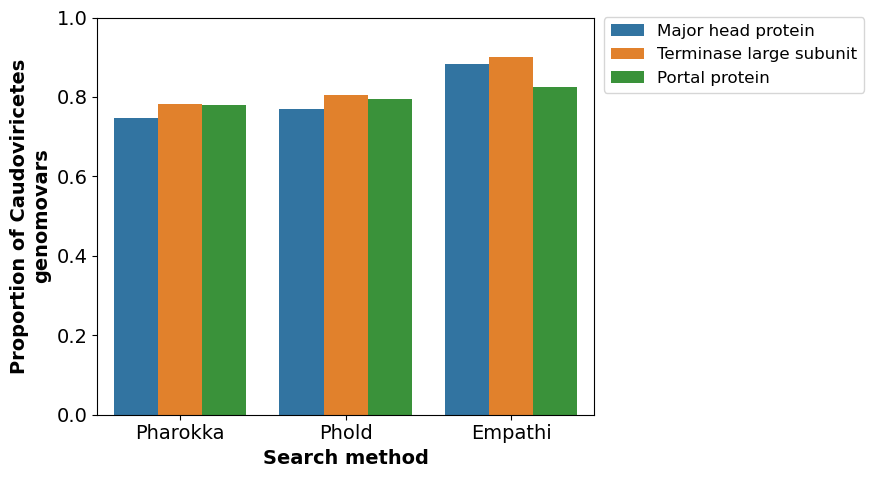

In [21]:
## Cumulative single-copy hallmarks in Caudoviricetes genomovars
# Mirrors figure_s11: Pharokka -> Phold -> Empathi cumulative coverage of
# single-copy major head / terminase large subunit / portal proteins.

caudo_genomovars = (
    pl.scan_csv(
        META,
        separator='\t',
        null_values=['', 'NA'],
    )
    .filter(
        (pl.col('uhvdb_id') == pl.col('genomovar_rep'))
        & (pl.col('ictv_class') == 'Caudoviricetes')
    )
    .select(pl.col('uhvdb_id').alias('genomovar_rep'))
    .unique()
)

try:
    caudo_genomovars = caudo_genomovars.collect(engine='streaming')
except TypeError:
    caudo_genomovars = caudo_genomovars.collect(streaming=True)

n_caudo_genomovars = caudo_genomovars.height
print(f'Caudoviricetes genomovar representatives: {n_caudo_genomovars:,}')

caudo_ann_lf = (
    pl.scan_parquet(ANN)
    .select(['genomovar_rep', 'pharokka_annot', 'phold_annot', 'empathi_annot'])
    .join(caudo_genomovars.lazy(), on='genomovar_rep', how='semi')
    .rename({
        'pharokka_annot': 'annot',
        'phold_annot': 'product',
        'empathi_annot': 'Annotation',
    })
)

try:
    caudo_ann = caudo_ann_lf.collect(engine='streaming')
except TypeError:
    caudo_ann = caudo_ann_lf.collect(streaming=True)

print(f'Caudoviricetes protein annotation rows: {caudo_ann.height:,}')

method_order = ['annot', 'product', 'Annotation']
method_label_map = {
    'annot': 'Pharokka',
    'product': 'Phold',
    'Annotation': 'Empathi',
}

hallmark_method_filters = {
    'Major head protein': {
        'annot': pl.col('annot') == 'major head protein',
        'product': pl.col('product') == 'major head protein',
        'Annotation': pl.col('Annotation') == 'pvp|capsid|major_capsid',
    },
    'Terminase large subunit': {
        'annot': pl.col('annot') == 'terminase large subunit',
        'product': pl.col('product') == 'terminase large subunit',
        'Annotation': pl.col('Annotation') == 'DNA-associated|terminase|packaging_assembly',
    },
    'Portal protein': {
        'annot': pl.col('annot') == 'portal protein',
        'product': pl.col('product') == 'portal protein',
        'Annotation': pl.col('Annotation') == 'pvp|portal',
    },
}

cumulative_rows = []
for hallmark_label, per_method_filter in hallmark_method_filters.items():
    cumulative_ids = set()
    for i, method in enumerate(method_order, start=1):
        method_ids = set(
            caudo_ann
                .filter(per_method_filter[method])
                .group_by('genomovar_rep')
                .len()
                .filter(pl.col('len') == 1)
                ['genomovar_rep']
        )
        cumulative_ids.update(method_ids)
        cumulative_rows.append({
            'Hallmark': hallmark_label,
            'step': i,
            'method_added': method,
            'method_label': method_label_map[method],
            'n_genomovars_single_copy_cumulative': len(cumulative_ids),
        })

cumulative_single_copy = (
    pl.DataFrame(cumulative_rows)
        .with_columns(
            (pl.col('n_genomovars_single_copy_cumulative') / n_caudo_genomovars)
                .alias('prop_genomovars_single_copy_cumulative')
        )
)

print(cumulative_single_copy)

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=cumulative_single_copy.to_pandas(),
    x='method_label',
    y='prop_genomovars_single_copy_cumulative',
    hue='Hallmark',
)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0, fontsize=12)
plt.xlabel('Search method', fontdict={'fontweight': 'bold'})
plt.ylabel('Proportion of Caudoviricetes\ngenomovars', fontdict={'fontweight': 'bold'})
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTDIR / 'figure_3c_caudo_hallmarks_r6.png', dpi=300, bbox_inches='tight')
plt.show()


In [22]:
## Proportion of Caudoviricetes genomovars with >= 2 single-copy hallmarks
# Uses the final (Pharokka + Phold + Empathi) single-copy sets from the previous cell.

single_copy_by_hallmark = {}
for hallmark_label, per_method_filter in hallmark_method_filters.items():
    hallmark_ids = set()
    for method in method_order:
        method_ids = set(
            caudo_ann
                .filter(per_method_filter[method])
                .group_by('genomovar_rep')
                .len()
                .filter(pl.col('len') == 1)
                ['genomovar_rep']
        )
        hallmark_ids.update(method_ids)
    single_copy_by_hallmark[hallmark_label] = hallmark_ids
    print(f'{hallmark_label}: {len(hallmark_ids):,} genomovars with single-copy gene')

hallmark_counts = (
    caudo_genomovars
        .with_columns([
            pl.col('genomovar_rep').is_in(single_copy_by_hallmark['Major head protein']).alias('has_mcp'),
            pl.col('genomovar_rep').is_in(single_copy_by_hallmark['Terminase large subunit']).alias('has_terl'),
            pl.col('genomovar_rep').is_in(single_copy_by_hallmark['Portal protein']).alias('has_portal'),
        ])
        .with_columns(
            (
                pl.col('has_mcp').cast(pl.Int8)
                + pl.col('has_terl').cast(pl.Int8)
                + pl.col('has_portal').cast(pl.Int8)
            ).alias('n_single_copy_hallmarks')
        )
)

n_ge2 = hallmark_counts.filter(pl.col('n_single_copy_hallmarks') >= 2).height
prop_ge2 = n_ge2 / n_caudo_genomovars

summary = (
    hallmark_counts
        .group_by('n_single_copy_hallmarks')
        .len()
        .sort('n_single_copy_hallmarks')
        .with_columns(
            (pl.col('len') / n_caudo_genomovars).alias('proportion')
        )
)
print(summary)
print(f'Genomovars with >= 2 single-copy hallmarks: {n_ge2:,} / {n_caudo_genomovars:,} ({prop_ge2:.4%})')
prop_ge2


Major head protein: 714,466 genomovars with single-copy gene
Terminase large subunit: 729,305 genomovars with single-copy gene
Portal protein: 667,353 genomovars with single-copy gene
shape: (4, 3)
┌─────────────────────────┬────────┬────────────┐
│ n_single_copy_hallmarks ┆ len    ┆ proportion │
│ ---                     ┆ ---    ┆ ---        │
│ i8                      ┆ u32    ┆ f64        │
╞═════════════════════════╪════════╪════════════╡
│ 0                       ┆ 15920  ┆ 0.019671   │
│ 1                       ┆ 39079  ┆ 0.048286   │
│ 2                       ┆ 190942 ┆ 0.235927   │
│ 3                       ┆ 563387 ┆ 0.696117   │
└─────────────────────────┴────────┴────────────┘
Genomovars with >= 2 single-copy hallmarks: 754,329 / 809,328 (93.2044%)


0.9320436213747701

In [ ]:
## Genomovars with >= 2 single-copy hallmarks by cumulative search method
# Pharokka alone -> Pharokka+Phold -> Pharokka+Phold+Empathi

method_stages = [
    (['annot'], 'Pharokka'),
    (['annot', 'product'], 'Pharokka + Phold'),
    (['annot', 'product', 'Annotation'], 'Pharokka + Phold + Empathi'),
]

stage_rows = []
for methods, label in method_stages:
    single_copy = {}
    for hallmark_label, per_method_filter in hallmark_method_filters.items():
        hallmark_ids = set()
        for method in methods:
            method_ids = set(
                caudo_ann
                    .filter(per_method_filter[method])
                    .group_by('genomovar_rep')
                    .len()
                    .filter(pl.col('len') == 1)
                    ['genomovar_rep']
            )
            hallmark_ids.update(method_ids)
        single_copy[hallmark_label] = hallmark_ids

    counts = (
        caudo_genomovars
            .with_columns([
                pl.col('genomovar_rep').is_in(single_copy['Major head protein']).alias('has_mcp'),
                pl.col('genomovar_rep').is_in(single_copy['Terminase large subunit']).alias('has_terl'),
                pl.col('genomovar_rep').is_in(single_copy['Portal protein']).alias('has_portal'),
            ])
            .with_columns(
                (
                    pl.col('has_mcp').cast(pl.Int8)
                    + pl.col('has_terl').cast(pl.Int8)
                    + pl.col('has_portal').cast(pl.Int8)
                ).alias('n_single_copy_hallmarks')
            )
    )
    n_ge2 = counts.filter(pl.col('n_single_copy_hallmarks') >= 2).height
    stage_rows.append({
        'methods': label,
        'n_ge2_hallmarks': n_ge2,
        'n_caudo_genomovars': n_caudo_genomovars,
        'proportion': n_ge2 / n_caudo_genomovars,
    })
    print(
        f'{label}: {n_ge2:,} / {n_caudo_genomovars:,} '
        f'({n_ge2 / n_caudo_genomovars:.2%}) with >= 2 single-copy hallmarks'
    )

pl.DataFrame(stage_rows)